In [1]:
import numpy as np
import pandas as pd
#tensorflow version 2.0
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

#reading data
mnist_train = pd.read_csv('../input/digit-recognizer/train.csv')
mnist_test = pd.read_csv('../input/digit-recognizer/test.csv')

In [2]:
mnist_train.shape,mnist_test.shape

((42000, 785), (28000, 784))

In [3]:
#standardization
mnist_train.iloc[:,1:] /= 255

#splitting features and target column
x_train = mnist_train.iloc[:,1:]
y_train = mnist_train.iloc[:,0]
x_test= mnist_test/255

#further splitting train set into validation and training set
x_train,x_validate,y_train,y_validate = train_test_split(x_train,y_train,test_size = 0.3,random_state = 12345)

Let's have a look at the images in our dataset.

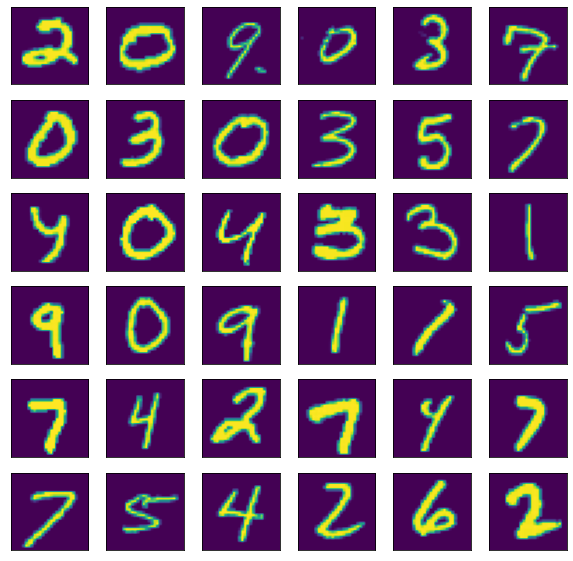

In [4]:
plt.figure(figsize=(10, 10))
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.array(x_test.iloc[i]).reshape(28,28))
plt.show()

Let's see if our data is balanced.

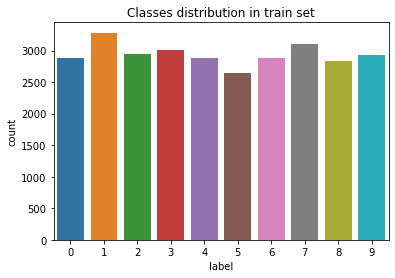

In [5]:
sns.countplot(y_train)
plt.title('Classes distribution in train set');

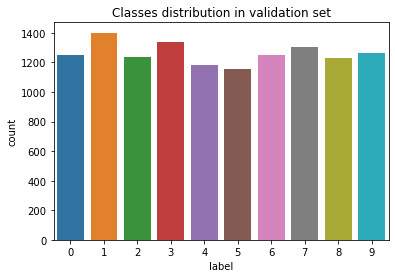

In [6]:
sns.countplot(y_validate)
plt.title('Classes distribution in validation set');

# Convolutional Neural Network

The term deep neural nets refers to any neural network with several hidden layers. Convolutional neural nets are a specific type of deep neural net which are especially useful for image recognition. Specifically, convolutional neural nets use convolutional and pooling layers, which reflect the translation-invariant nature of most images.

For this, we need to reshape our input data.

In [7]:
image_rows = 28
image_cols = 28
image_shape = (image_rows,image_cols,1)
x_train = tf.reshape(x_train,[x_train.shape[0],*image_shape])
x_test = tf.reshape(x_test,[x_test.shape[0],*image_shape])
x_validate = tf.reshape(x_validate,[x_validate.shape[0],*image_shape])

Now we define our model. The layer in model network (keras.layers.Flatten) transforms the format of the images from a two-dimensional array (of 28 by 28 pixels) to a one-dimensional array (of 28 * 28 = 784 pixels). This layer unstacks rows of pixels in the image and lining them up and has no parameters to learn; it only reformats the data. Pooling layers are then added to further reduce the number of parameters.

After the pixels are flattened, the network consists of a sequence of two keras.layers.Dense layers. These are densely connected, or fully connected, neural layers.

A problem with training neural networks is in the choice of the number of training epochs to use. Too many epochs can lead to overfitting of the training dataset, whereas too few may result in an underfit model. Early stopping is a method that allows you to specify an arbitrary large number of training epochs and stop training once the model performance stops improving on a hold out validation dataset.

In [8]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu',input_shape = image_shape),
    tf.keras.layers.MaxPooling2D(pool_size=2) ,# down sampling the output instead of 28*28 it is 14*14
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu',input_shape = image_shape),
    tf.keras.layers.MaxPooling2D(pool_size=2) ,
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(), # flatten out the layers
    tf.keras.layers.Dense(200,activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(200,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(25,activation = 'softmax')
])

cnn_model.compile(loss ='sparse_categorical_crossentropy',
                  optimizer='adam',metrics =['accuracy'])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=8)

history = cnn_model.fit(
    x_train,
    y_train,
    batch_size=500,
    epochs=60,
    verbose=1,
    validation_data=(x_validate,y_validate),
    callbacks=early_stop
)

Epoch 1/60
59/59 [==============================] - 12s 200ms/step - loss: 1.4825 - accuracy: 0.5156 - val_loss: 0.3244 - val_accuracy: 0.9063
Epoch 2/60
59/59 [==============================] - 12s 198ms/step - loss: 0.3486 - accuracy: 0.8929 - val_loss: 0.1443 - val_accuracy: 0.9556
Epoch 3/60
59/59 [==============================] - 12s 198ms/step - loss: 0.2100 - accuracy: 0.9344 - val_loss: 0.0977 - val_accuracy: 0.9712
Epoch 4/60
59/59 [==============================] - 12s 203ms/step - loss: 0.1567 - accuracy: 0.9527 - val_loss: 0.0786 - val_accuracy: 0.9757
Epoch 5/60
59/59 [==============================] - 12s 201ms/step - loss: 0.1317 - accuracy: 0.9595 - val_loss: 0.0662 - val_accuracy: 0.9783
Epoch 6/60
59/59 [==============================] - 11s 191ms/step - loss: 0.1135 - accuracy: 0.9652 - val_loss: 0.0637 - val_accuracy: 0.9817
Epoch 7/60
59/59 [==============================] - 11s 190ms/step - loss: 0.0984 - accuracy: 0.9698 - val_loss: 0.0572 - val_accuracy: 0.9825

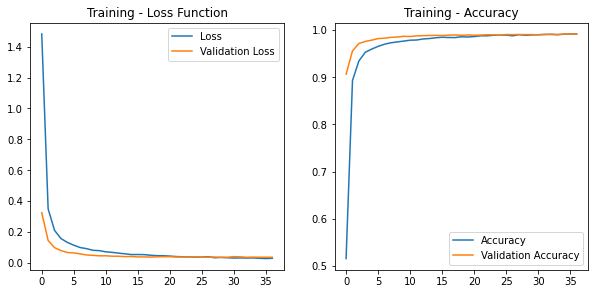

In [9]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training - Loss Function')

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training - Accuracy');

In [10]:
# Making submissions
submissions = pd.read_csv('../input/digit-recognizer/sample_submission.csv')
submissions['Label'] = cnn_model.predict_classes(x_test)
submissions.to_csv('submission.csv',index=False)

***Please upvote and provide suggestions.***